# Ampere Analysis Notebook

This notebook demonstrates how to load HPL traces using the `ampere` library and visualize energy consumption.
Now running on **Arkouda** for scalable server-side processing.

In [70]:
TRACE="/Users/adam/Downloads/cycles-16384"

In [71]:
from IPython.display import display
import re
from ampere import Ensemble, Metric, MetricConfig, MetricType, AmpereSession, Visualizer, connect
import arkouda as ak
import numpy as np
import matplotlib.pyplot as plt
import os
# Connect to Arkouda (registers cleanup automatically)
connect(server="localhost", port=5555)

connected to arkouda server tcp://*:5555


Connecting to Arkouda server at localhost:5555...


In [72]:
os.system(f"cd {TRACE} && ~/otf2csv ./traces.otf2")

Converting trace at ./traces.otf2 to CSV...










Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]










Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]






Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]









Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]








Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]











Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]












Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]













Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]
















Processing Process Master thread:   0%|          | 0/4 [00:00<?, ?event/s]














Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]

















Processing Process Orphan thread 1:   0%|          | 0/131078 [00:00<?, ?event/s]


















 ... (more hidden) ...















Processing Process :   0%|          | 0/12504 [00:00<?, ?event/s]






Reading completed in 12.82 seconds.


Writing Call Graphs:  20%|██        | 2/10 [00:00<00:01,  7.37file/s]

Writing completed in 1.88 seconds.
All done in 14.70 seconds (0.25 minutes).


Writing Metrics: 100%|██████████| 1/1 [00:00<00:00, 79.33file/s]


0

In [73]:
# Define Metric Configs
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*violation.*"): MetricConfig(MetricType.CUMULATIVE),
    re.compile(r".*rocm.*clk.*"): MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-9),
}

# Define Topology Resolver
def my_hpc_topology(metric_name, ranks):
    # if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    # if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    # if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=1' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    # if 'device=3' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0']]
    return ranks

In [74]:
# ranks = [f"MPI Rank {i}" for i in range(8)]
ranks = ["Process"]
topo = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths([TRACE], topo, configs)


Loading Runs: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


<Axes: title={'center': 'Energy Consumption Over Time'}, xlabel='Time (s)', ylabel='Energy (J)'>

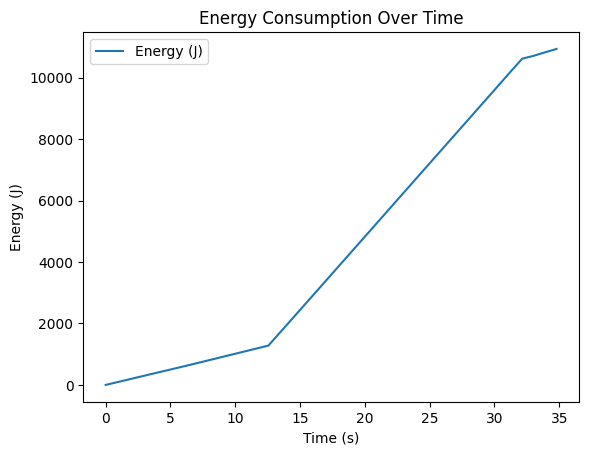

In [75]:
# Graph the energy over time for each GPU
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::energy_count:device=0"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Energy (J)": y.values
})

df = df.to_pandas()
initial_energy = df["Energy (J)"][0]
df["Energy (J)"] = df["Energy (J)"] - initial_energy

df.plot.line(x="Timestamp", y="Energy (J)", title="Energy Consumption Over Time", xlabel="Time (s)", ylabel="Energy (J)")

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...
0.016781609195402298


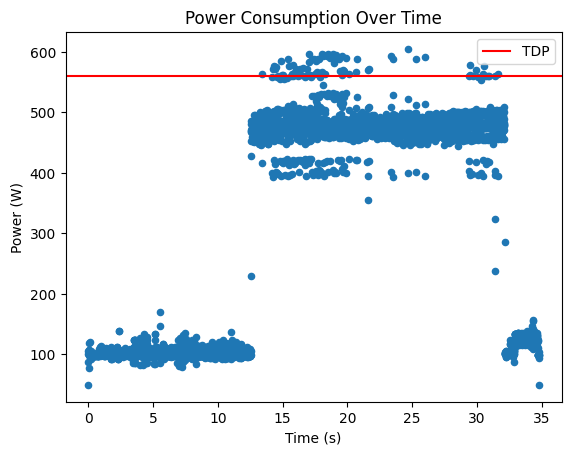

In [76]:

def numerical_derivative(func, h=0.001):
    return lambda t: (func(t + h) - func(t - h)) / (2 * h)

# Derive instantaneous power from cumulative energy
def calc_power(energy_metric):
    t = energy_metric.times.to_ndarray()
    e = energy_metric.values.to_ndarray()
    f = lambda x: np.interp(x, t, e)
    f = numerical_derivative(f)
    # dt = t[1:] - t[:-1]
    # de = e[1:] - e[:-1]
    # power = de / dt
    power = f(t)
    # power = ak.where((power < 0) | (dt <= 0), 0.0, power)
    return Metric("power", ak.array(t), ak.array(power), MetricConfig(MetricType.INSTANTANEOUS))

for d in [0, 2, 4, 6]:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        calc_power,
        f"A2rocm_smi:::energy_count:device={d}"
    )

# Graph the energy over time for each GPU
y = ensemble.runs[0].nodes[0].metrics["A2rocm_smi:::inst_power:device=0"]
df = ak.DataFrame({
    "Timestamp": y.times,
    "Power (W)": y.values
})

df = df.to_pandas()

print(len(df[df['Power (W)'] > 560]) / len(df['Power (W)']))
df.plot.scatter(x="Timestamp", y="Power (W)", title="Power Consumption Over Time", xlabel="Time (s)", ylabel="Power (W)")
plt.axhline(560, color='red', label="TDP")
plt.legend()